In [1]:
import os
import numpy as np
import cv2
from PIL import Image
from matplotlib import pyplot as plt

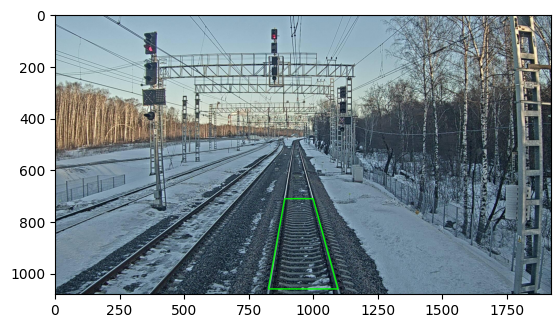

In [30]:
path = r'./image_new.jpg'
img = Image.open(path)
w, h = img.size
img = np.array(img)

top_left = (887, 712)
top_right = (997, 712)
bottom_left = (824, 1060)
bottom_right = (1093, 1060)

# Параметры линии: цвет Green (B=0, G=255, R=0) и толщина 3 пикселя
color = (0, 255, 0)
thickness = 3

# 3. Рисуем 4 линии по периметру
cv2.line(img, top_left, top_right, color, thickness)       # Верхняя линия
cv2.line(img, top_right, bottom_right, color, thickness)   # Правая линия
cv2.line(img, bottom_right, bottom_left, color, thickness) # Нижняя линия
cv2.line(img, bottom_left, top_left, color, thickness)     # Левая линия

plt.imshow(img)

(28522, 14268, 3)


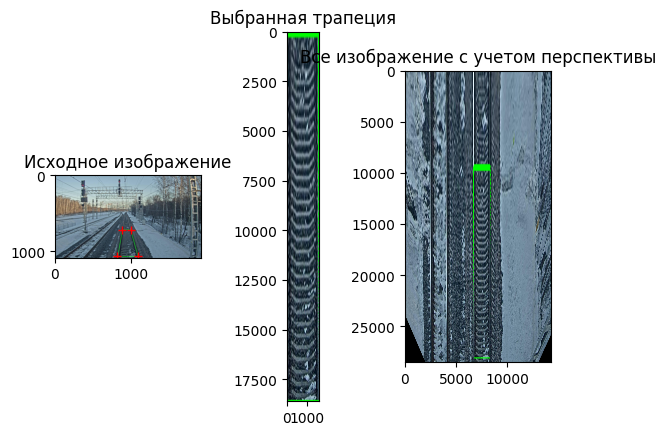

In [31]:
fig, (asrc, anorm, afull) = plt.subplots(1, 3)

asrc.set_title('Исходное изображение')
anorm.set_title('Выбранная трапеция')
afull.set_title('Все изображение с учетом перспективы')

asrc.imshow(img)

# Координаты углов трапеции по картинке (тут получены вручную)
top_left = [887, 712]
top_right = [997, 712]
bottom_left = [824, 1060]
bottom_right = [1093, 1060]
img_points = np.float32([top_left, top_right, bottom_left, bottom_right])

# Показать кординаты углов на картинке
asrc.plot(*img_points.T, marker='+', color='red', linewidth=0)

# координаты этих же точек на бумаге (*10, чтобы было видно картинку)
wmm = 1600
hmm = 18600
real_pointst = np.float32([[0, 0], [wmm, 0], [0, hmm], [wmm, hmm]])

# Вычисление матрицы коррекции перспективы
pmatrix = cv2.getPerspectiveTransform(img_points, real_pointst)

# выпрямленная картинка в пределах угла трапеции
cropped = cv2.warpPerspective(np.array(img), pmatrix, (wmm, hmm))

# Показать выпрямленную картинку
anorm.imshow(cropped)

# Пересчет всей картинки (не только в пределах координат трапеции)

# Углы исходной каринки
corners = np.float32([[0, 0], [w, 0], [0, h], [w, h]]).reshape(-1, 1, 2)
# Положение этих точек в реальном пространстве (применяем к ним матрицу коррекции перспективы)
t_corners = cv2.perspectiveTransform(corners, pmatrix)
# Границы изображения в реальном пространстве
x_min, y_min = t_corners.min(axis=0).ravel()
x_max, y_max = t_corners.max(axis=0).ravel()
# Размеры области
new_w = int(np.ceil(x_max - x_min))
new_h = int(np.ceil(y_max - y_min))

# Матрица переноса (сдвиг картинки в положительную область
pmatrix_shift = np.array([[1, 0, -x_min],
                          [0, 1, y_min/2],
                          [0, 0, 1]])
# Произведение матрицы переноса и матрицы перспективы
pmatrix_new = pmatrix_shift @ pmatrix



# полная картинка
corr = cv2.warpPerspective(np.array(img), pmatrix_new, (new_w, new_h))

afull.imshow(corr)
print(corr.shape)
plt.show()


In [39]:
# np.save('./data/pmatrix_new.npy', pmatrix_new)
# np.save('./data/new_w.npy', new_w)
# np.save('./data/new_h.npy', new_h)

pmatrix_new = np.load('./data/pmatrix_new.npy')
new_w = int(np.load('./data/new_w.npy'))
new_h = int(np.load('./data/new_h.npy'))

In [3]:
src = r'./data/3/masks'
img_fs = [os.path.join(src, f) for f in os.listdir(src) if f.endswith('.jpg')]
msk_fs = [os.path.join(src, f) for f in os.listdir(src) if f.endswith('.npy')]

import re
coord = []

for f in msk_fs:
    match = re.search(r'(\d+\.\d)', f)
    if match:
        result = match.group(1)
        coord.append(float(result))

coord = coord[:66]
print(coord[:10])
len(coord)

[80843.7, 80851.4, 80858.1, 80864.7, 80872.6, 80881.3, 80890.5, 80899.2, 80907.7, 80919.1]


66

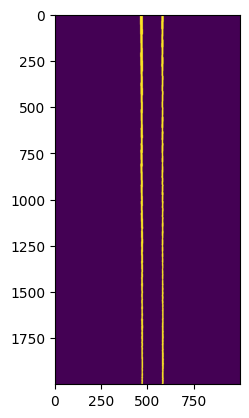

In [ ]:
def load_warp(mask_path):
    mask = np.load(mask_path)
    mask = np.array(mask, dtype=np.uint8)
    res = cv2.warpPerspective(mask, pmatrix_new, (new_w, new_h))
    res[:, :int(res.shape[1]/3)] = 0
    res[:, -int(res.shape[1]/3):] = 0
    return res

def resize(arr):
    scale = 2000 / max(arr.shape)
    display_res = cv2.resize(arr, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
    return display_res

# fig, ax = plt.subplots()

# # mask_pr = load_warp(r"D:\Projects\perspective\data\3\080843.789.jpg")
mask_pr = load_warp(msk_fs[0])

plt.imshow(resize(mask_pr))

In [ ]:
mask_cont = np.zeros_like(mask_pr)
contours, _ = cv2.findContours(mask_pr, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
cv2.drawContours(mask_cont, contours, -1, 1, 3)

plt.imshow(mask_cont)

In [ ]:
# картинку брал по частям гориз срезами, считал  центр масс контуров

centroids = []
st = 0
step = 100
for en in range(step, mask_cont.shape[1], step):

    contours, _ = cv2.findContours(mask_pr[st:en, :], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    for contour in contours:
        M = cv2.moments(contour)
        if M["m00"] != 0:  # Проверяем, чтобы избежать деления на ноль
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            centroids.append((cx, cy+st))

    st += step

X = np.array(centroids)[:, 0]
Y = np.array(centroids)[:, 1]

diff = np.diff(Y)

# средние точки между центрами масс кусков контуров
mid_p = []
for i, v in enumerate(diff):
    if v < 3:
        mid_p.append([X[i] - int((X[i] - X[i+1]) / 2), Y[i]])
mid_p = np.array(mid_p)

plt.imshow(mask_cont)
plt.scatter(X, Y)
plt.scatter(mid_p[:, 0], mid_p[:, 1]);


In [ ]:
# Интеролировать серединки

y_centr = np.arange(mask_cont.shape[0])
x_centr = np.interp(y_centr, mid_p[:, 1], mid_p[:, 0])
plt.imshow(mask_cont)
plt.plot(x_centr, y_centr);

# сделать функцию по такому типу, но обратную,
# когда на вход смещенный у, на выходе х

In [ ]:
# mask_cont = Image.fromarray(mask_cont)
# mask_cont.save('mask_cont.jpg')

In [ ]:
# открывается следующая картинка, выравнивается, вырезается ее часть до след координаты
# и вставляется в основное, совмещая центры
# взять нижнюю точку между рельсами на след картинке и учитывая координаты (у) поставить ее на центральной линии.

mask_nxt = load_warp(msk_fs[24])
mask_nxt_p = mask_nxt[-181:, :]
print(mask_nxt_p.shape)

# простой вариант на попробовать
# находит центр между рельсами
x_min = np.where(mask_nxt[-2, :] == 1)[0][0]
x_max = np.where(mask_nxt[-2, :] == 1)[0][-1]
m_p = x_min + ((x_max - x_min) // 2)

plt.imshow(mask_nxt_p)
plt.scatter(m_p, mask_nxt_p.shape[0]-1)
print(m_p)

# тест сопоставления
mask_test = np.zeros_like(mask_nxt_p)
t_p = 500
bord = 200

mask_test[:, t_p:t_p+bord] = mask_nxt_p[:, m_p:m_p+bord]  # справа от точки
mask_test[:, t_p-bord:t_p] = mask_nxt_p[:, m_p-bord:m_p]  # справа от точки

plt.imshow(mask_test)

### проба в цикл

In [ ]:
# 25 # 16054.942 основ
# 24 # 16053.3 след
# ...

# 8.8мм в однм пикселе

# если идти вперед, отступ в пикселях на центр-ой линии
def coord2pix(c1, c2):
    return abs(int(((c1 - c2) * 1000) / 8.8))


# координаты в target points на изобр

st_p = coord[25]  # стартовая картинка/коорд
t_ps = []
t_v = 0           # temp val
for c in coord[24:12:-1]:
    print(c)
    res = coord2pix(st_p, c)
    res += t_v
    t_v = res
    t_ps.append(res)
    st_p = c

t_ps
# [181, 362, 532, 713, 883, 1053, 1223, 1393, 1608]


In [ ]:
# проба в цикл

# для высот картинок

diff = np.diff(t_ps, prepend=0)

mask_res = mask_cont.copy()
bord = 200  # область захвата

fig, ax = plt.subplots()

for h, p, name in zip(diff, t_ps, msk_fs[24:12:-1]):  # порядок другой - коор идут вверх, а поезд едет в обратном напр
    print(h, p, name)
    mask_nxt = load_warp(name)
    mask_nxt_p = mask_nxt[-h:, :]
    # точка между рельсами, по ней будет срез
    x_min = np.where(mask_nxt[-4, :] == 1)[0][0]
    x_max = np.where(mask_nxt[-4, :] == 1)[0][-1]
    m_p = x_min + ((x_max - x_min) // 2)

    t_p = round(x_centr[-p])

    mask_res[-p-h:-p, t_p:t_p+bord] = mask_nxt_p[:, m_p:m_p+bord]
    mask_res[-p-h:-p, t_p-bord:t_p] = mask_nxt_p[:, m_p-bord:m_p]

    # plt.axhline(round(y_centr[-p]))
    # plt.imshow(mask_nxt_p)
    # plt.show()

plt.imshow(mask_res)

# TODO на стыках встречаются пробелы, хотя на исходниках всё норм. косяк.jpg


In [ ]:
# ТЕСТОВЫЦ ВАРИАНТ
# пока куски по точкам
# для высот картинок

diff = np.diff(t_ps, prepend=0)

mask_res = mask_cont.copy()
bord = 200  # область захвата

fig, ax = plt.subplots()

for h, p, name in zip(diff, t_ps, msk_fs[24:12:-1]):  # порядок другой - коор идут вверх, а поезд едет в обратном напр
    print(h, p, name)
    mask_nxt = load_warp(name)
    mask_nxt_p = mask_nxt[-h:, :]
    # точка между рельсами, по ней будет срез
    y = -4

    x_min = np.where(mask_nxt[y, :] == 1)[0][0]
    x_max = np.where(mask_nxt[y, :] == 1)[0][-1]
    m_p = x_min + ((x_max - x_min) // 2)

    t_p = round(x_centr[-p])
    print('t_p', t_p)

    # точки входа рельсов на осн изобр
    # _l = m_p - x_min
    # _r = x_max - m_p
    # plt.scatter([t_p - _l, t_p + _r], [mask_res.shape[1]-p-h, mask_res.shape[1]-p-h])

    # перенос срезов на осн изобр
    mask_res[-p-h:-p, t_p:t_p+bord] = mask_nxt_p[:, m_p:m_p+bord]
    mask_res[-p-h:-p, t_p-bord:t_p] = mask_nxt_p[:, m_p-bord:m_p]



    # plt.axhline(round(y_centr[-p]))
    # plt.imshow(mask_nxt_p)
    # plt.show()

plt.imshow(mask_res)

# TODO на стыках встречаются пробелы, хотя на исходниках всё норм. косяк.jpg


In [ ]:
name

In [ ]:
# преобразовать в точки
fig, ax = plt.subplots(2, 1, sharex=True)

ax[0].imshow(mask_nxt_p)

dots = []
for row in range(mask_nxt_p.shape[0]):
    x_min = np.where(mask_nxt_p[row, :] == 1)[0][0]
    x_max = np.where(mask_nxt_p[row, :] == 1)[0][-1]
    m_p = x_min + ((x_max - x_min) // 2)
    # точки входа рельсов на осн изобр
    # _l = m_p - x_min
    # _r = x_max - m_p
    # dots.append((m_p - _l, row))
    # dots.append((m_p + _r, row))
    dots.append((x_max, row))
    dots.append((x_min, row))



dots = np.array(dots)
ax[1].invert_yaxis()
# ax[1].scatter(dots[:, 0], dots[:, 1], s=1)
ax[1].scatter(dots[[0, 1, 2, 3, -1, -2, -3, -4], 0], dots[[0, 1, 2, 3, -1, -2, -3, -4], 1], s=1)


In [ ]:
dots = np.where(mask_nxt_p == 1)
dots = np.vstack((dots[0], dots[1])).T
dots = dots[:, [1, 0]]
plt.scatter(dots[:, 0], dots[:, 1])

In [ ]:
t_p

In [ ]:
d:\Projects\Tr_lights\data\20190218_151610_c1\040873.846.jpg

In [ ]:
# взять 10 рядов у нижн грани и вычислить среднее значение для коорд центра
# среднее знач для столбика х
m_p = np.array([np.mean(dots[-10:-1, 0]), dots[-1, 1]])


dy = np.array([m_p[0], 0])

# разница между текущим t_p и следующим
dx = np.array([m_p[0] - 19, 0])


print(m_p, dx)

In [ ]:
np.arctan2(*(m_p-dx)[::-1])

In [ ]:
# x, y  bl br tr tl

# rect = np.array([[100, 0], [150, 0], [150, mask_nxt_p.shape[0]], [100, mask_nxt_p.shape[0]]])
# rect = np.array([[100, 0],
#                  [150, 0],
#                  [150, 180],
#                  [100, 180]])
rect = dots
# Точка, вокруг которой повернуть
pivot_point = np.array([1250, 0])

# Угол поворота
theta = 1.46
c, s = np.cos(theta), np.sin(theta)
rotation_matrix = np.array([
    [c, -s],
    [s,  c]
])

shifted_rect = rect - pivot_point
rotated_shit_rectangle = (rotation_matrix @ shifted_rect.T).T
rotated_rectangle = rotated_shit_rectangle + pivot_point

plt.scatter(rect[:, 0], rect[:, 1])
plt.scatter(rotated_rectangle[:, 0], rotated_rectangle[:, 1])
plt.axis('equal')


In [ ]:


x = x_centr[100:900]
y = y_centr[100:900]

coef = np.polyfit(y, x, 1)
f = np.poly1d(coef)
x_lin = f(y)

plt.plot(x_centr[100:900], y_centr[100:900])
plt.plot(x_lin, y)


In [ ]:
def get_perp(x_arr, y_arr):
    coef = np.polyfit(y_arr, x_arr, 1)
    f = np.poly1d(coef)
    x_lin = f(y_arr)


In [ ]:
# 1. Исходная наклонная линия (отрезки x и y)
p1 = np.array([1.0, 2.0])  # Начало
p2 = np.array([4.0, 6.0])  # Конец (точка пересечения)

# 2. Расчет направляющего вектора линии
v = p2 - p1

# 3. Нахождение перпендикулярного вектора (поворот на 90 градусов)
# Для вектора (x, y) перпендикуляр равен (-y, x)
v_perp = np.array([-v[1], v[0]])

# 4. Нормирование перпендикуляра (задаем нужную длину, например, 2 единицы)
length = 2.0  # будет равно bord
v_perp_normalized = v_perp / np.linalg.norm(v_perp) * length

# 5. Вычисление конечной точки перпендикуляра
p3 = p2 + v_perp_normalized
p4 = p2 - v_perp_normalized


plt.figure(figsize=(6, 6))
plt.plot([p1[0], p2[0]], [p1[1], p2[1]], "b-o")
plt.plot([p3[0], p4[0]], [p3[1], p4[1]], "r-o")

plt.grid(True)
plt.axis("equal")
plt.show()
